# Ejercicio 2 — Análisis de Datos y Red Neuronal con Prompting

**Módulo: Python para IA** | Máster en Inteligencia Artificial

**Tipo**: Autoevaluable | **Sesión**: 2
**Fecha límite**: Antes de la Sesión 3

---

### Instrucciones

1. **Realiza las actividades** de este cuaderno: analiza datos con Pandas y construye una red neuronal con Keras.
2. Usa **Gemini, Copilot, o cualquier herramienta de IA** para ayudarte.
3. Las celdas de validación te ayudarán a saber si vas bien ✅
4. **Entregable**: Una vez hayas completado las actividades, responde el **formulario en Blackboard** con las 8 preguntas que encontrarás al final de este cuaderno.

---
## Parte A — Análisis de Datos con Pandas

Analiza el siguiente dataset de ventas.

In [2]:
import pandas as pd
import numpy as np

# Dataset de ventas — NO MODIFICAR
np.random.seed(42)
datos_ventas = {
    "producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Laptop",
                 "Mouse", "Teclado", "Monitor", "Laptop", "Mouse",
                 "Teclado", "Monitor", "Laptop", "Mouse", "Teclado",
                 "Monitor", "Laptop", "Mouse", "Teclado", "Monitor"],
    "categoria": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Electrónica",
                   "Accesorios", "Accesorios", "Electrónica", "Electrónica", "Accesorios",
                   "Accesorios", "Electrónica", "Electrónica", "Accesorios", "Accesorios",
                   "Electrónica", "Electrónica", "Accesorios", "Accesorios", "Electrónica"],
    "precio": [999, 25, 75, 350, 1099, 30, 80, 400, 899, 20,
               65, 320, 1199, 35, 90, 380, 950, 28, 70, 360],
    "cantidad": [3, 15, 8, 5, 2, 20, 10, 3, 4, 25,
                 12, 4, 1, 18, 7, 6, 3, 22, 9, 5],
    "mes": ["Ene", "Ene", "Ene", "Ene", "Feb", "Feb", "Feb", "Feb",
            "Mar", "Mar", "Mar", "Mar", "Abr", "Abr", "Abr", "Abr",
            "May", "May", "May", "May"]
}

df = pd.DataFrame(datos_ventas)
df["ingreso_total"] = df["precio"] * df["cantidad"]
print(df.head(10))
print(f"Shape: {df.shape}")

  producto    categoria  precio  cantidad  mes  ingreso_total
0   Laptop  Electrónica     999         3  Ene           2997
1    Mouse   Accesorios      25        15  Ene            375
2  Teclado   Accesorios      75         8  Ene            600
3  Monitor  Electrónica     350         5  Ene           1750
4   Laptop  Electrónica    1099         2  Feb           2198
5    Mouse   Accesorios      30        20  Feb            600
6  Teclado   Accesorios      80        10  Feb            800
7  Monitor  Electrónica     400         3  Feb           1200
8   Laptop  Electrónica     899         4  Mar           3596
9    Mouse   Accesorios      20        25  Mar            500
Shape: (20, 6)


### A.1 — Ingreso total global

Calcula la suma de la columna `ingreso_total`.

In [4]:
# A.1 — Calcula el ingreso total
ingreso_total_global = df['ingreso_total'].sum() # Tu cálculo aquí
print(f"Ingreso total: {ingreso_total_global}")

Ingreso total: 27311


In [6]:
# Validación A.1 — NO MODIFICAR
assert ingreso_total_global == 27311, f"Error: debería ser 28792, obtuviste {ingreso_total_global}"
print("✅ A.1 — Ingreso total: CORRECTO")

✅ A.1 — Ingreso total: CORRECTO


### A.2 — Producto con mayor ingreso total

¿Qué producto genera más ingreso total (sumando todas sus ventas)?

In [8]:
# A.2 — Producto con mayor ingreso
producto_top = df.groupby('producto')['ingreso_total'].sum().idxmax()
print(f"Producto top: {producto_top}")

Producto top: Laptop


In [9]:
# Validación A.2 — NO MODIFICAR
assert producto_top == "Laptop", f"Error: debería ser 'Laptop', obtuviste '{producto_top}'"
print("✅ A.2 — Producto top: CORRECTO")

✅ A.2 — Producto top: CORRECTO


### A.3 — Media de precio por categoría

Calcula el precio medio por categoría. Devuelve un diccionario redondeado a 2 decimales.

In [10]:
# A.3 — Precio medio por categoría
precio_medio_categoria = df.groupby('categoria')['precio'].mean().round(2).to_dict()
print(f"Precio medio: {precio_medio_categoria}")

Precio medio: {'Accesorios': 51.8, 'Electrónica': 695.6}


In [11]:
# Validación A.3 — NO MODIFICAR
assert precio_medio_categoria == {"Accesorios": 51.8, "Electrónica": 695.6}, \
    f"Error: {precio_medio_categoria}"
print("✅ A.3 — Precio medio por categoría: CORRECTO")

✅ A.3 — Precio medio por categoría: CORRECTO


### A.4 — Mes más rentable

¿Qué mes tiene el mayor ingreso total?

In [12]:
# A.4 — Mes m!s rentable
mes_top = df.groupby('mes')['ingreso_total'].sum().idxmax()
print(f"Mes m!s rentable: {mes_top}")

Mes m!s rentable: Mar


In [15]:
# Validación A.4 — NO MODIFICAR
assert mes_top == "Mar", f"Error: debería ser 'Mar', obtuviste '{mes_top}'"
print("✅ A.4 — Mes más rentable: CORRECTO")

✅ A.4 — Mes más rentable: CORRECTO


---
## Parte B — Red Neuronal con Keras

Construye un clasificador para **Fashion-MNIST** y alcanza un accuracy > 85%.

In [16]:
import tensorflow as tf
from tensorflow import keras

# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Nombres de las clases
clases = ["Camiseta", "Pantalón", "Jersey", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {clases}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Clases: ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']


### B.1 — Construye el modelo

Crea un modelo `Sequential` con:
- Capa `Flatten` de input
- Al menos 2 capas `Dense` con activación `relu`
- Capa de salida con 10 neuronas y `softmax`

> 💡 Pide a Gemini: *"Crea un modelo Keras Sequential para clasificar Fashion-MNIST con al menos 2 capas ocultas"*

In [17]:
# B.1 — Define tu modelo aquí
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compilar
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 — Entrena el modelo

Entrena el modelo y consigue un **accuracy en test > 85%**.

In [18]:
# B.2 — Entrena tu modelo
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8224 - loss: 0.5009 - val_accuracy: 0.8302 - val_loss: 0.4287
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8644 - loss: 0.3759 - val_accuracy: 0.8577 - val_loss: 0.3894
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8764 - loss: 0.3374 - val_accuracy: 0.8663 - val_loss: 0.3664
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8841 - loss: 0.3152 - val_accuracy: 0.8600 - val_loss: 0.3616
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8907 - loss: 0.2935 - val_accuracy: 0.8687 - val_loss: 0.3503
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8946 - loss: 0.2820 - val_accuracy: 0.8783 - val_loss: 0.3295
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8977 - loss: 0.2706 - val_accuracy: 0.8793 - val_loss: 0.3416
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9036 - loss: 0.2586 -

In [19]:
# B.2 — Eval&a en test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy en test: {accuracy}")

Accuracy en test: 0.8862000107765198


In [ ]:
# Validación B.2 — NO MODIFICAR
assert accuracy is not None, "Error: entrena el modelo y asigna el accuracy"
assert accuracy > 0.85, f"Error: accuracy debe ser > 0.85, obtuviste {accuracy:.4f}"
print(f"✅ B.2 — Accuracy: {accuracy:.4f} (> 85%): CORRECTO")

### B.3 — Predicción

Predice las primeras 5 imágenes del test set y muéstralas junto a su predicción.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


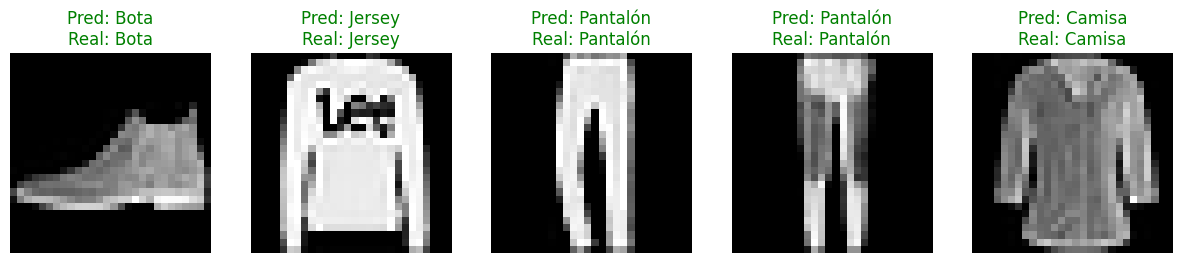

In [20]:
# B.3 — Predice y visualiza las primeras 5 imágenes
import matplotlib.pyplot as plt
import numpy as np

# Realizar predicciones sobre las primeras 5 imágenes
predicciones = model.predict(x_test[:5])

# Visualización
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    # np.argmax nos da el índice con la mayor probabilidad
    clase_predicha = clases[np.argmax(predicciones[i])]
    clase_real = clases[y_test[i]]

    color = "green" if clase_predicha == clase_real else "red"
    plt.title(f"Pred: {clase_predicha}\nReal: {clase_real}", color=color)
    plt.axis("off")

plt.show()

---
## Parte C — Escribe una Spec (Opcional)

Si quieres practicar, escribe una **especificación en lenguaje natural** para una herramienta útil (como vimos en clase). Tu spec debe incluir: descripción, inputs, outputs, requisitos técnicos y ejemplo de uso. Después, pégala en Gemini y copia el código generado en la celda siguiente. Esto no es obligatorio pero es excelente práctica de prompting.

In [22]:
spec = """
# Spec: Sales Summary Pro

## Descripción
Una función que toma un DataFrame de ventas y genera un informe resumido con métricas clave y una visualización de barras.

## Inputs
- df: DataFrame de Pandas con columnas 'producto', 'categoria' e 'ingreso_total'.

## Outputs
- Un diccionario con: ingreso_total_acumulado, producto_estrella, y categoria_lider.
- Un gráfico de barras de ingresos por producto.

## Requisitos técnicos
- Usar Pandas para agregaciones.
- Usar Matplotlib para el gráfico.
- Manejar errores si las columnas no existen.

## Ejemplo
resumen = generar_reporte_ventas(df)
"""
print(spec)


# Spec: Sales Summary Pro

## Descripción
Una función que toma un DataFrame de ventas y genera un informe resumido con métricas clave y una visualización de barras.

## Inputs
- df: DataFrame de Pandas con columnas 'producto', 'categoria' e 'ingreso_total'.

## Outputs
- Un diccionario con: ingreso_total_acumulado, producto_estrella, y categoria_lider.
- Un gráfico de barras de ingresos por producto.

## Requisitos técnicos
- Usar Pandas para agregaciones.
- Usar Matplotlib para el gráfico.
- Manejar errores si las columnas no existen.

## Ejemplo
resumen = generar_reporte_ventas(df)



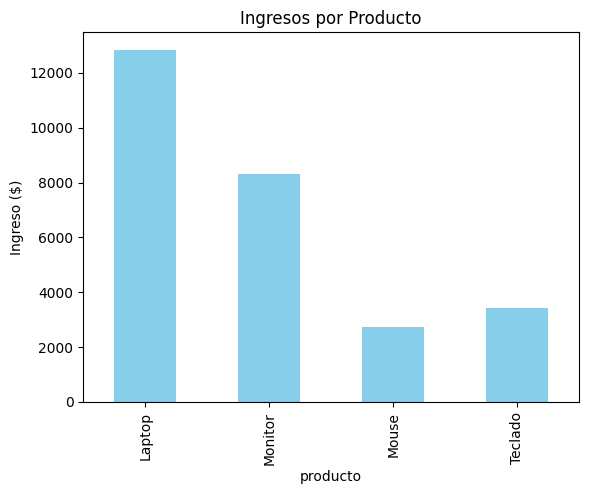

--- Informe Generado ---
{'ingreso_total_acumulado': np.int64(27311), 'producto_estrella': 'Laptop', 'categoria_lider': 'Electrónica'}


In [23]:
import matplotlib.pyplot as plt

def generar_reporte_ventas(dataframe):
    try:
        # Cálculos
        total = dataframe['ingreso_total'].sum()
        prod_top = dataframe.groupby('producto')['ingreso_total'].sum().idxmax()
        cat_top = dataframe.groupby('categoria')['ingreso_total'].sum().idxmax()

        # Gráfico
        dataframe.groupby('producto')['ingreso_total'].sum().plot(kind='bar', color='skyblue')
        plt.title('Ingresos por Producto')
        plt.ylabel('Ingreso ($)')
        plt.show()

        return {
            "ingreso_total_acumulado": total,
            "producto_estrella": prod_top,
            "categoria_lider": cat_top
        }
    except KeyError as e:
        return f"Error: Falta la columna {e}"

# Probar la herramienta con el df actual
resultado = generar_reporte_ventas(df)
print("--- Informe Generado ---")
print(resultado)

---
## 📋 Responde en Blackboard

Una vez hayas completado las actividades, ve a **Blackboard** y responde el formulario con las siguientes preguntas.

---

### Pregunta 1 (Verdadero / Falso)

**Un array de NumPy solo puede contener elementos del mismo tipo de dato (por ejemplo, todos enteros o todos floats).**

---

### Pregunta 2 (Multirespuesta)

**¿Qué método de Pandas se usa para agrupar datos y calcular agregaciones (por ejemplo, media por categoría)?**

- a) `merge()`
- b) `groupby()`
- c) `pivot()`
- d) `sort_values()`

---

### Pregunta 3 (Verdadero / Falso)

**En el dataset de ventas del ejercicio (Parte A), el producto con mayor ingreso total es el "Monitor".**

---

### Pregunta 4 (Multirespuesta)

**En Keras, ¿qué función de activación se usa típicamente en la capa de salida para clasificación multiclase (10 categorías)?**

- a) relu
- b) sigmoid
- c) softmax
- d) tanh

---

### Pregunta 5 (Verdadero / Falso)

**La técnica de prompting "Chain of Thought" consiste en pedirle al modelo que razone paso a paso antes de dar la respuesta final.**

---

### Pregunta 6 (Multirespuesta)

**¿Qué hace la capa `Flatten` en un modelo Keras para clasificar imágenes de Fashion-MNIST (28×28)?**

- a) Normaliza los píxeles entre 0 y 1
- b) Aplica una convolución para detectar bordes
- c) Convierte la imagen 28×28 en un vector de 784 elementos
- d) Reduce las dimensiones usando PCA

---

### Pregunta 7 (Verdadero / Falso)

**Fashion-MNIST contiene imágenes de 28×28 píxeles en escala de grises.**

---

### Pregunta 8 (Multirespuesta)

**¿Qué función de pérdida (loss) se usa para clasificación multiclase con etiquetas enteras en Keras?**

- a) `binary_crossentropy`
- b) `mean_squared_error`
- c) `sparse_categorical_crossentropy`
- d) `hinge`